# 🫀 Phân loại Bệnh Tim - Heart Disease Classification

**Mục tiêu:** Dự đoán nguy cơ mắc bệnh tim dựa trên các chỉ số y tế.

**Dữ liệu:** UCI Heart Disease Dataset (920 bệnh nhân, 14 đặc trưng)

## 1. Import thư viện

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             ConfusionMatrixDisplay, roc_curve)

plt.rcParams['figure.dpi'] = 120
sns.set_style("whitegrid")
print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## 2. Load và khám phá dữ liệu

In [28]:
df = pd.read_csv("../data/heart.csv")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Shape: (920, 16)

Columns: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [30]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Total missing: 1759


In [31]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## 3. Tiền xử lý dữ liệu

In [32]:
# Bỏ cột không cần thiết
df_clean = df.drop(['id', 'dataset'], axis=1)

# Chuyển bool -> int (có thể có NaN)
df_clean['fbs'] = df_clean['fbs'].map({True: 1, False: 0, 1: 1, 0: 0})
df_clean['exang'] = df_clean['exang'].map({True: 1, False: 0, 1: 1, 0: 0})

# Nhãn nhị phân: 0 = không bệnh, 1 = có bệnh
df_clean['target'] = (df_clean['num'] > 0).astype(int)
df_clean = df_clean.drop('num', axis=1)

print("Phân phối nhãn (target):")
print(df_clean['target'].value_counts())
print(f"\nTỉ lệ mắc bệnh: {df_clean['target'].mean()*100:.1f}%")

Phân phối nhãn (target):
target
1    509
0    411
Name: count, dtype: int64

Tỉ lệ mắc bệnh: 55.3%


In [33]:
# One-hot encoding cho biến phân loại
cat_cols = ['sex', 'cp', 'restecg', 'slope', 'thal']
df_encoded = pd.get_dummies(df_clean, columns=cat_cols)

X = df_encoded.drop('target', axis=1)
y = df_encoded['target']
feature_columns = X.columns.tolist()

print(f"Số đặc trưng sau encoding: {len(feature_columns)}")
print(f"Đặc trưng: {feature_columns}")

Số đặc trưng sau encoding: 23
Đặc trưng: ['age', 'trestbps', 'chol', 'fbs', 'thalch', 'exang', 'oldpeak', 'ca', 'sex_Female', 'sex_Male', 'cp_asymptomatic', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'restecg_lv hypertrophy', 'restecg_normal', 'restecg_st-t abnormality', 'slope_downsloping', 'slope_flat', 'slope_upsloping', 'thal_fixed defect', 'thal_normal', 'thal_reversable defect']


## 4. Phân tích dữ liệu (EDA)

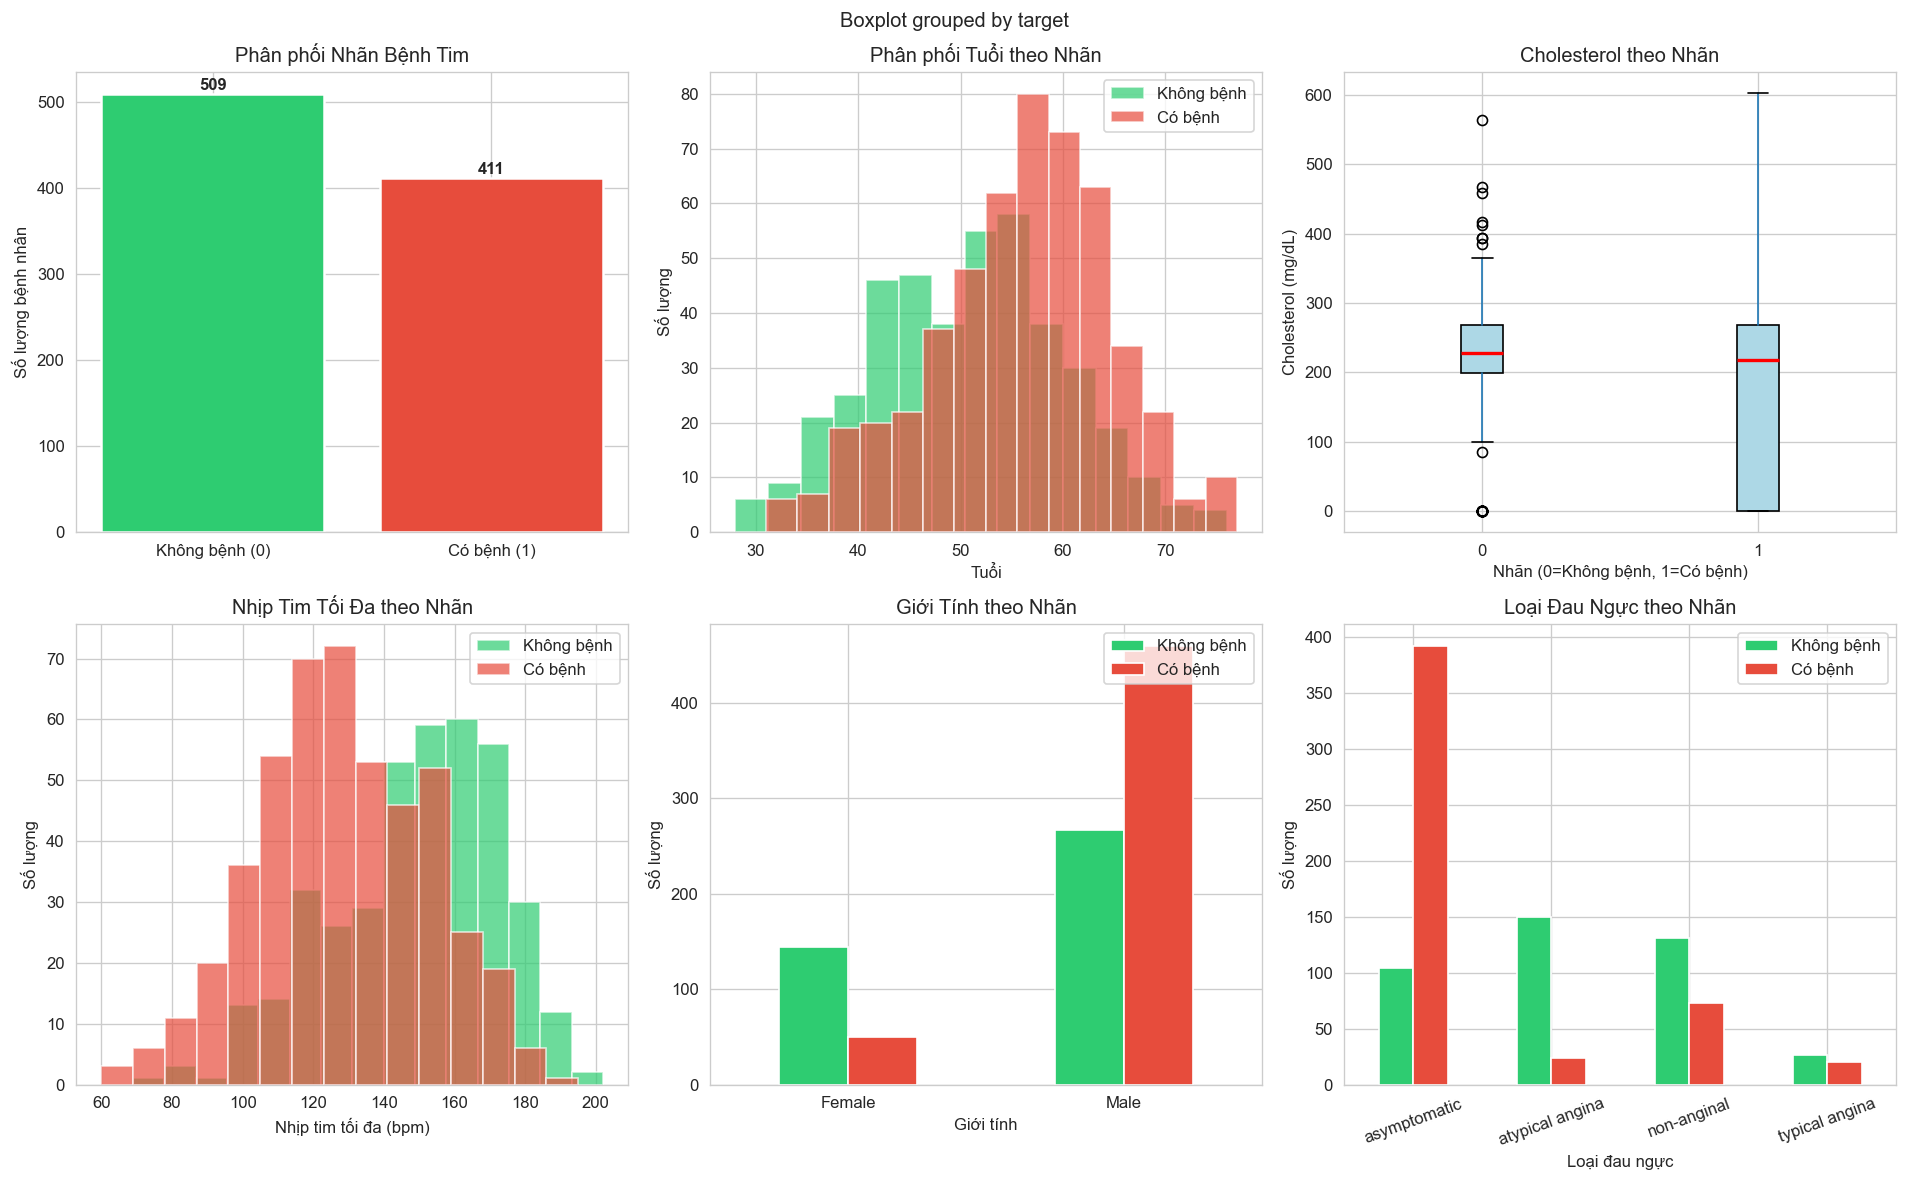

✅ EDA charts saved to eda_charts.png


In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Phân tích Dữ liệu Bệnh Tim', fontsize=16, fontweight='bold')

# 1. Phân phối nhãn
ax1 = axes[0, 0]
counts = df_clean['target'].value_counts()
colors = ['#2ecc71', '#e74c3c']
ax1.bar(['Không bệnh (0)', 'Có bệnh (1)'], counts.values, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_title('Phân phối Nhãn Bệnh Tim')
ax1.set_ylabel('Số lượng bệnh nhân')
for i, v in enumerate(counts.values):
    ax1.text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2. Tuổi theo nhãn
ax2 = axes[0, 1]
for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Không bệnh', 'Có bệnh']):
    ax2.hist(df_clean[df_clean['target'] == label]['age'], alpha=0.7,
             bins=15, color=color, label=name, edgecolor='white')
ax2.set_title('Phân phối Tuổi theo Nhãn')
ax2.set_xlabel('Tuổi')
ax2.set_ylabel('Số lượng')
ax2.legend()

# 3. Cholesterol theo nhãn
ax3 = axes[0, 2]
df_clean.boxplot(column='chol', by='target', ax=ax3,
                 patch_artist=True,
                 boxprops=dict(facecolor='lightblue'),
                 medianprops=dict(color='red', linewidth=2))
ax3.set_title('Cholesterol theo Nhãn')
ax3.set_xlabel('Nhãn (0=Không bệnh, 1=Có bệnh)')
ax3.set_ylabel('Cholesterol (mg/dL)')
plt.sca(ax3)
plt.title('Cholesterol theo Nhãn')

# 4. Nhịp tim tối đa
ax4 = axes[1, 0]
for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Không bệnh', 'Có bệnh']):
    ax4.hist(df_clean[df_clean['target'] == label]['thalch'], alpha=0.7,
             bins=15, color=color, label=name, edgecolor='white')
ax4.set_title('Nhịp Tim Tối Đa theo Nhãn')
ax4.set_xlabel('Nhịp tim tối đa (bpm)')
ax4.set_ylabel('Số lượng')
ax4.legend()

# 5. Giới tính theo nhãn
ax5 = axes[1, 1]
sex_disease = pd.crosstab(df_clean['sex'], df_clean['target'])
sex_disease.plot(kind='bar', ax=ax5, color=['#2ecc71', '#e74c3c'],
                 edgecolor='white', rot=0)
ax5.set_title('Giới Tính theo Nhãn')
ax5.set_xlabel('Giới tính')
ax5.set_ylabel('Số lượng')
ax5.legend(['Không bệnh', 'Có bệnh'], loc='upper right')

# 6. Loại đau ngực
ax6 = axes[1, 2]
cp_disease = pd.crosstab(df_clean['cp'], df_clean['target'])
cp_disease.plot(kind='bar', ax=ax6, color=['#2ecc71', '#e74c3c'],
                edgecolor='white', rot=20)
ax6.set_title('Loại Đau Ngực theo Nhãn')
ax6.set_xlabel('Loại đau ngực')
ax6.set_ylabel('Số lượng')
ax6.legend(['Không bệnh', 'Có bệnh'])

plt.tight_layout()
plt.savefig('../assets/eda_charts.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ EDA charts saved to eda_charts.png")

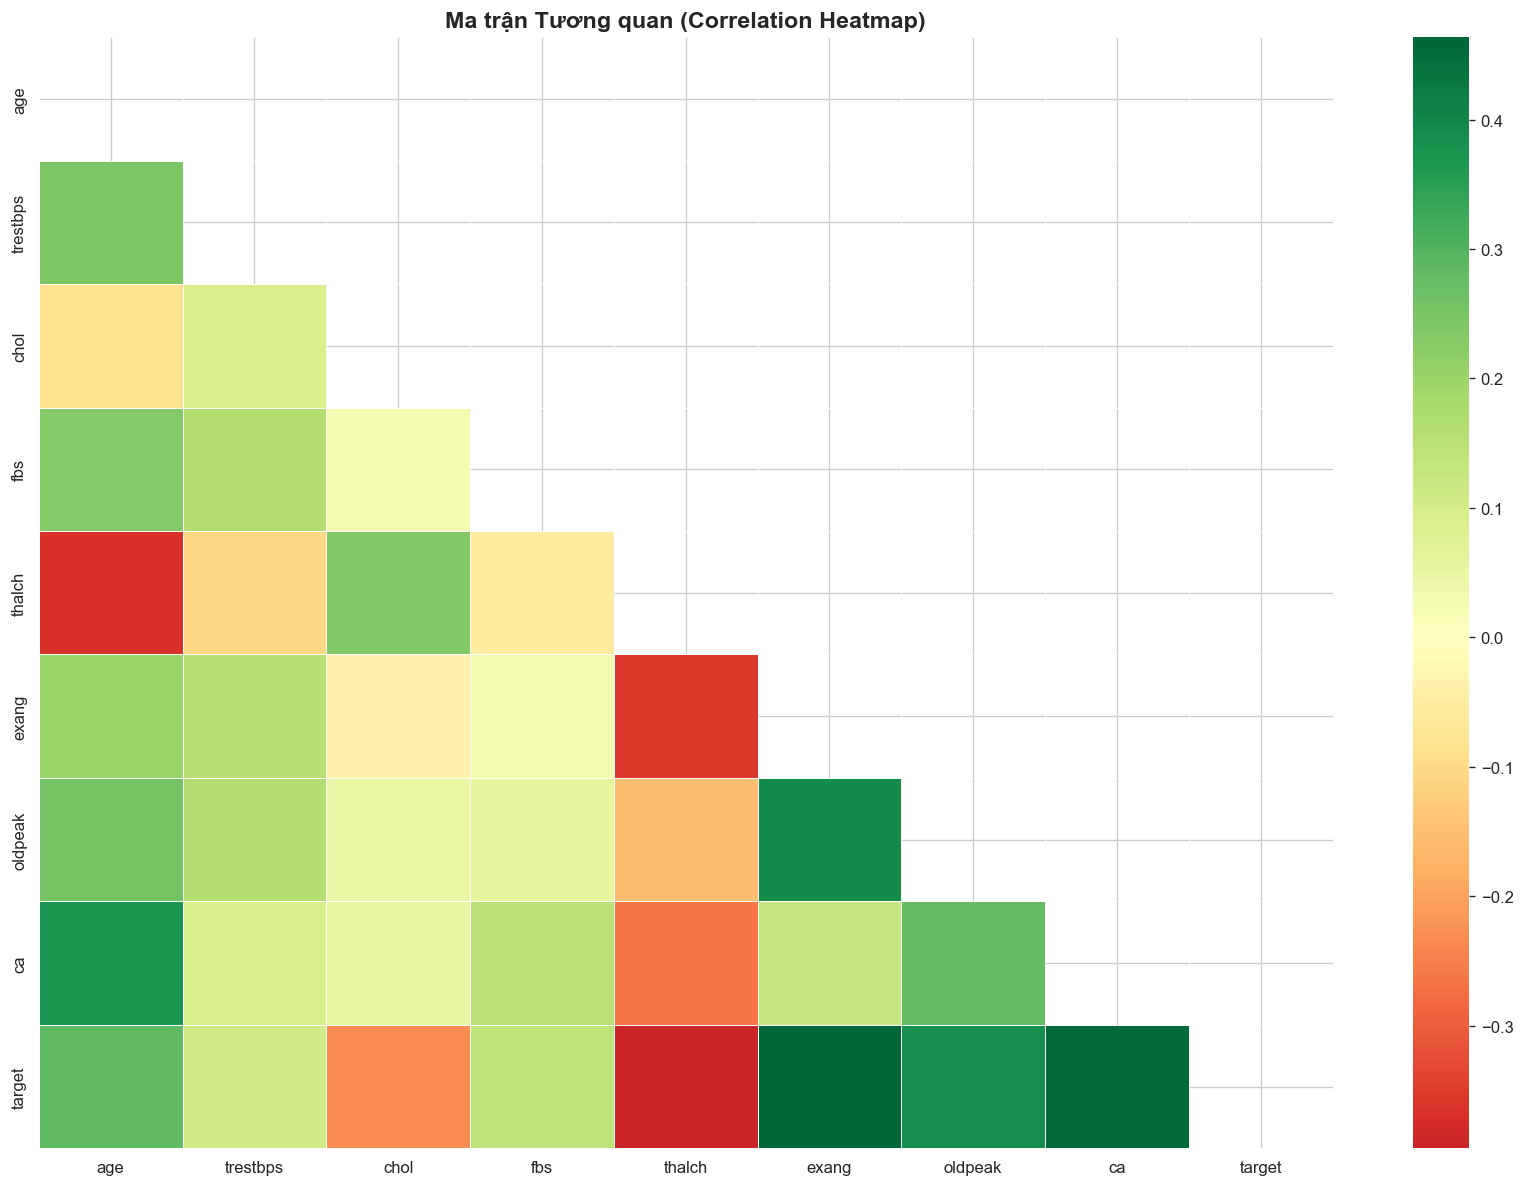

In [35]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
numeric_df = df_encoded.select_dtypes(include=[np.number])
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdYlGn',
            center=0, linewidths=0.3, fmt='.2f')
plt.title('Ma trận Tương quan (Correlation Heatmap)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

### Kết luận từ phân tích dữ liệu
- **Tuổi:** Bệnh nhân có bệnh tim thường lớn tuổi hơn (trung bình ~55 tuổi)
- **Giới tính:** Nam giới có tỉ lệ mắc bệnh cao hơn nữ giới
- **Đau ngực:** Bệnh nhân có triệu chứng "asymptomatic" (không triệu chứng điển hình) lại có tỉ lệ mắc bệnh cao nhất
- **Nhịp tim:** Nhịp tim tối đa thấp hơn liên quan đến nguy cơ mắc bệnh cao hơn
- **Cholesterol:** Phân phối cholesterol ở hai nhóm không chênh lệch nhiều

## 5. Tách Train/Test & Chuẩn hóa

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Xử lý giá trị thiếu
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc = scaler.transform(X_test_imp)

print(f"Train size: {X_train_sc.shape}")
print(f"Test size: {X_test_sc.shape}")

Train size: (736, 23)
Test size: (184, 23)


## 6. Xây dựng & Huấn luyện Mô hình

In [37]:
# Gradient Boosting Classifier - mô hình mạnh cho bài toán phân loại có bảng số
model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    min_samples_split=5,
    subsample=0.8,
    random_state=42
)

model.fit(X_train_sc, y_train)
print("✅ Model trained successfully!")

# Cross-validation
cv_scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='accuracy')
print(f"\nCross-validation (5-fold):")
print(f"  Scores: {[f'{s:.4f}' for s in cv_scores]}")
print(f"  Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

✅ Model trained successfully!

Cross-validation (5-fold):
  Scores: ['0.8176', '0.8095', '0.8299', '0.7551', '0.8231']
  Mean: 0.8071 ± 0.0268


## 7. Đánh giá Mô hình

In [38]:
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)
cr_dict = classification_report(y_test, y_pred, output_dict=True)

print(f"🎯 Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"📊 ROC-AUC:   {auc:.4f}")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Không bệnh', 'Có bệnh']))

🎯 Accuracy:  0.8424 (84.24%)
📊 ROC-AUC:   0.8875

📋 Classification Report:
              precision    recall  f1-score   support

  Không bệnh       0.85      0.78      0.82        82
     Có bệnh       0.83      0.89      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



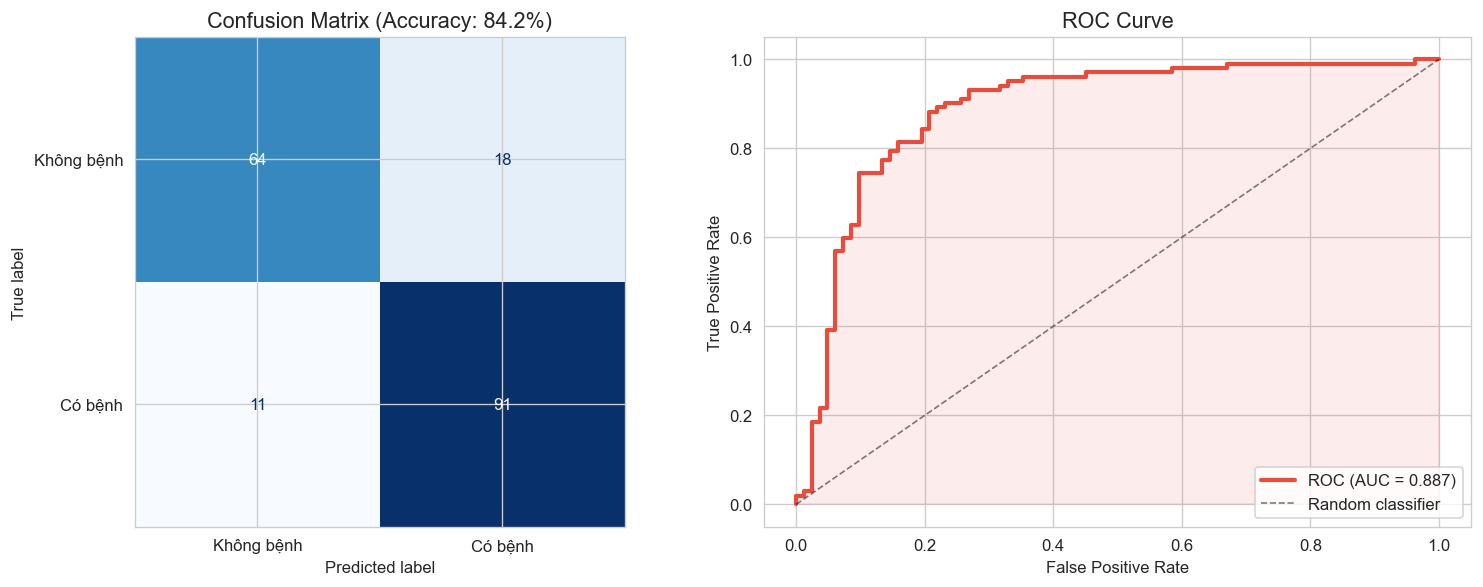

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Không bệnh', 'Có bệnh'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix (Accuracy: {acc*100:.1f}%)', fontsize=13)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2.5, label=f'ROC (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('../assets/evaluation.png', bbox_inches='tight', dpi=150)
plt.show()

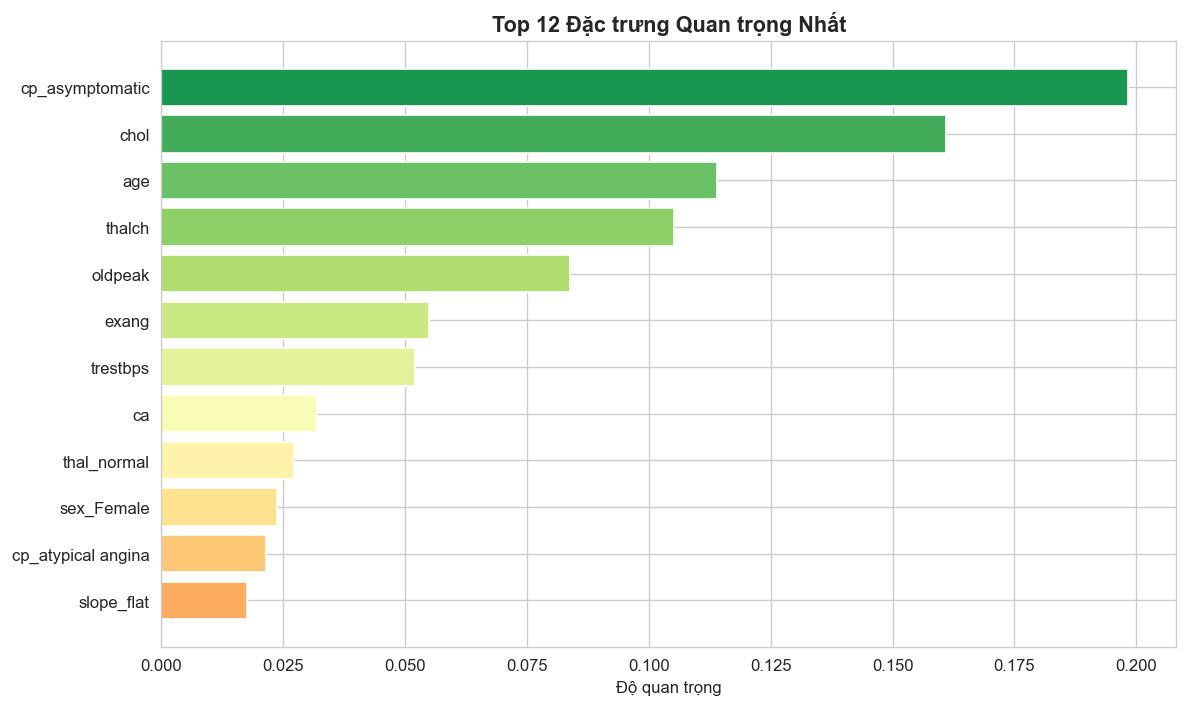

✅ Feature importance chart saved


In [40]:
# Feature Importance
fi = pd.Series(model.feature_importances_, index=feature_columns).sort_values(ascending=True).tail(12)

plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(fi)), fi.values, color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(fi))))
plt.yticks(range(len(fi)), fi.index)
plt.xlabel('Độ quan trọng')
plt.title('Top 12 Đặc trưng Quan trọng Nhất', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Feature importance chart saved")

## 8. Lưu Mô hình

In [41]:
fi_series = pd.Series(model.feature_importances_, index=feature_columns).sort_values(ascending=False)

joblib.dump({
    'model': model,
    'imputer': imputer,
    'scaler': scaler,
    'feature_columns': feature_columns,
    'accuracy': acc,
    'auc': auc,
    'confusion_matrix': cm,
    'classification_report': cr_dict,
    'feature_importance': fi_series
}, '../heart_model.h5')

print("✅ Model saved to heart_model.h5")
print(f"   Accuracy: {acc:.4f}")
print(f"   AUC:      {auc:.4f}")

✅ Model saved to heart_model.h5
   Accuracy: 0.8424
   AUC:      0.8875


## 9. Hàm Dự đoán Mẫu

In [42]:
def predict_heart(patient_data: dict) -> dict:
    """
    patient_data: dict với keys là tên cột gốc (age, sex, cp, trestbps, ...)
    """
    df_input = pd.DataFrame([patient_data])
    
    # Map bool-like values
    if 'fbs' in df_input:
        df_input['fbs'] = df_input['fbs'].map({True: 1, False: 0, 1: 1, 0: 0, 'True': 1, 'False': 0})
    if 'exang' in df_input:
        df_input['exang'] = df_input['exang'].map({True: 1, False: 0, 1: 1, 0: 0, 'True': 1, 'False': 0})
    
    # One-hot encode
    cat_cols = ['sex', 'cp', 'restecg', 'slope', 'thal']
    df_enc = pd.get_dummies(df_input, columns=[c for c in cat_cols if c in df_input.columns])
    
    # Align với training features
    df_enc = df_enc.reindex(columns=feature_columns, fill_value=0)
    
    # Impute + scale
    X_imp = imputer.transform(df_enc)
    X_sc = scaler.transform(X_imp)
    
    # Predict
    pred = model.predict(X_sc)[0]
    prob = model.predict_proba(X_sc)[0][1]
    
    # Ước tính mức độ
    if pred == 0:
        level = 0
    elif prob < 0.60:
        level = 1
    elif prob < 0.75:
        level = 2
    elif prob < 0.88:
        level = 3
    else:
        level = 4
    
    return {
        'prediction': int(pred),
        'probability': float(prob),
        'level': level
    }

# --- Test mẫu ---
sample = {
    'age': 63, 'sex': 'Male', 'cp': 'typical angina',
    'trestbps': 145, 'chol': 233, 'fbs': True,
    'restecg': 'normal', 'thalch': 150, 'exang': False,
    'oldpeak': 2.3, 'slope': 'downsloping', 'ca': 0, 'thal': 'fixed defect'
}

result = predict_heart(sample)
print(f"Kết quả dự đoán:")
print(f"  Có bệnh: {'Có' if result['prediction'] else 'Không'}")
print(f"  Xác suất: {result['probability']*100:.1f}%")
print(f"  Mức độ ước tính: {result['level']}/4")

Kết quả dự đoán:
  Có bệnh: Không
  Xác suất: 9.0%
  Mức độ ước tính: 0/4
